# Agglomerative_Clustering  for Multi-Building Energy Benchmarking

## 1-Load and sample data as Agglomerative is memory-heavy

In [2]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


pca_data = pd.read_csv("pca_data.csv")
clean_data = pd.read_csv("clean_data.csv")

print("Original PCA datapoints:", len(pca_data))
print("Original clean datapoints:", len(clean_data))




# REDUCE SAMPLE SIZE
# Agglomerative is memory-heavy

sample_size = 20000

sample_index = pca_data.sample(
    n=min(sample_size, len(pca_data)),
    random_state=42
).index

pca_sample = pca_data.loc[sample_index].copy().reset_index(drop=True)
clean_sample = clean_data.loc[sample_index].copy().reset_index(drop=True)

print("Sampled datapoints:", len(pca_sample))



Original PCA datapoints: 135735
Original clean datapoints: 135735
Sampled datapoints: 20000


##2- Run agglomaretive clustering

In [3]:

X = pca_sample.copy()

model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels = model.fit_predict(X)

pca_sample["cluster"] = labels
clean_sample["cluster"] = labels

clustering_performance = pd.DataFrame([{
    "Method": "Agglomerative",
    "Clusters": len(set(labels)),
    "Silhouette": silhouette_score(X, labels),
    "Davies-Bouldin": davies_bouldin_score(X, labels),
    "Calinski-Harabasz": calinski_harabasz_score(X, labels)
}])

print("\n===== CLUSTERING PERFORMANCE =====")
print(clustering_performance)



===== CLUSTERING PERFORMANCE =====
          Method  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
0  Agglomerative         4    0.145678         1.85592        3603.265244


##3- Assess performance quality and benchmark

In [4]:

# BENCHMARKING QUALITY

benchmark_cols = ["site_eui", "ghg_emissions_int"]

cluster_mean = clean_sample.groupby("cluster")[benchmark_cols].mean()
cluster_std = clean_sample.groupby("cluster")[benchmark_cols].std()

cv = cluster_std / cluster_mean

avg_cv_site = cv["site_eui"].mean()
avg_cv_ghg = cv["ghg_emissions_int"].mean()

cv["avg_cv"] = (cv["site_eui"] + cv["ghg_emissions_int"]) / 2
best_avg_cluster_cv = cv["avg_cv"].min()
best_single_cv = cv[["site_eui", "ghg_emissions_int"]].min().min()

benchmark_quality = pd.DataFrame([{
    "Method": "Agglomerative",
    "Avg CV (site_eui)": avg_cv_site,
    "Avg CV (ghg_emissions)": avg_cv_ghg,
    "Best Avg Cluster CV": best_avg_cluster_cv,
    "Best Single CV": best_single_cv
}])

print("\n===== BENCHMARKING QUALITY =====")
print(benchmark_quality)

# 3. BENCHMARKING IMPROVEMENT


global_site = clean_sample["site_eui"].std()
global_ghg = clean_sample["ghg_emissions_int"].std()

cluster_sizes = clean_sample.groupby("cluster").size()

cluster_site_std = (
    cluster_std["site_eui"] * cluster_sizes
).sum() / cluster_sizes.sum()

cluster_ghg_std = (
    cluster_std["ghg_emissions_int"] * cluster_sizes
).sum() / cluster_sizes.sum()

improvement_site = (global_site - cluster_site_std) / global_site * 100
improvement_ghg = (global_ghg - cluster_ghg_std) / global_ghg * 100

benchmark_improvement = pd.DataFrame([{
    "Method": "Agglomerative",
    "Global Std (site_eui)": global_site,
    "Cluster Avg Std (site_eui)": cluster_site_std,
    "Improvement site_eui (%)": improvement_site,
    "Global Std (ghg_emissions)": global_ghg,
    "Cluster Avg Std (ghg_emissions)": cluster_ghg_std,
    "Improvement ghg_emissions (%)": improvement_ghg
}])

print("\n===== BENCHMARKING IMPROVEMENT =====")
print(benchmark_improvement)



# SAVE OUTPUTS

pca_sample.to_csv("agglomerative_clustered_pca_data.csv", index=False)
clean_sample.to_csv("agglomerative_clustered_clean_data.csv", index=False)

clustering_performance.to_csv("agglomerative_clustering_performance.csv", index=False)
benchmark_quality.to_csv("agglomerative_benchmark_quality.csv", index=False)
benchmark_improvement.to_csv("agglomerative_benchmark_improvement.csv", index=False)

print("\nFiles saved successfully.")


===== BENCHMARKING QUALITY =====
          Method  Avg CV (site_eui)  Avg CV (ghg_emissions)  \
0  Agglomerative           0.396306                0.401933   

   Best Avg Cluster CV  Best Single CV  
0             0.340205         0.32478  

===== BENCHMARKING IMPROVEMENT =====
          Method  Global Std (site_eui)  Cluster Avg Std (site_eui)  \
0  Agglomerative              52.519183                   31.737353   

   Improvement site_eui (%)  Global Std (ghg_emissions)  \
0                  39.56998                    3.931393   

   Cluster Avg Std (ghg_emissions)  Improvement ghg_emissions (%)  
0                         2.275128                      42.129207  

Files saved successfully.


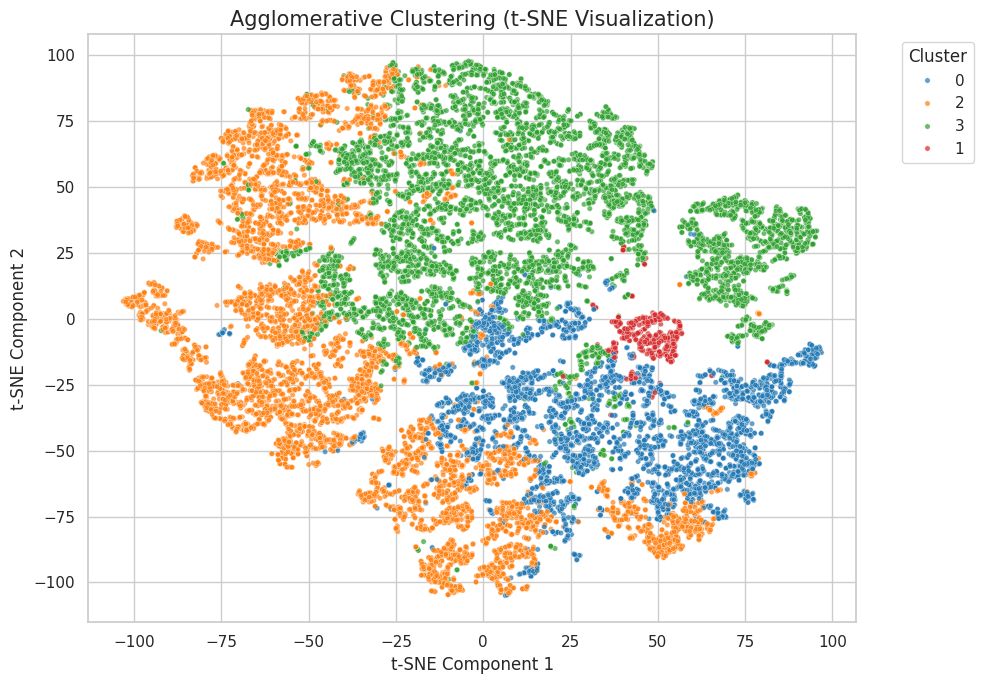

In [ ]:

# Agglomerative t-SNE Visualization

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels.astype(str),
    palette="tab10",
    s=15,
    alpha=0.7
)

plt.title("Agglomerative Clustering (t-SNE Visualization)", fontsize=15)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("agglomerative_tsne_visualization.png", dpi=300)
plt.show()